# Individualized Theta Frequency from Task-Locked EEG
## Feedback-Locked PLV + Power Analysis for tACS Frequency Selection

**Goal:** Estimate participant-specific theta frequency from EEG recorded during the two-armed bandit task, using the approach from Reinhart & Nguyen (2019, *Nature Neuroscience*).

**Reinhart & Nguyen method:** Compute phase-locking value (PLV) between prefrontal and temporal cortex across the theta band (4–8 Hz, 0.1 Hz steps) during the task maintenance window. The frequency with maximum mean PLV = individualized theta frequency (iTF). Stimulation applied with 0.5 Hz resolution.

**Adaptation for 7-electrode StarStim montage:** We can't do source-space analysis, so we compute sensor-space PLV between frontal channels (FCz, F3, F4) and posterior/lateral channels (FT7, P3, P4) during the feedback/outcome window (0–2000 ms post-feedback onset).

**Three complementary estimates:**
1. **PLV-based** (Reinhart method) — frequency of peak inter-electrode phase synchrony
2. **Power-based** — frequency of peak event-related theta power at frontal ROI
3. **Specparam on evoked spectrum** — aperiodic-corrected peak from feedback-locked epochs

**Montage:** 1=F3, 2=Fp1, 3=FCz, 4=FT7, 5=F4, 6=P4, 7=P3


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import signal
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
import warnings, time
warnings.filterwarnings('ignore', category=RuntimeWarning)

try:
    from specparam import SpectralModel
    SPECPARAM_AVAILABLE = True
    print(f"specparam v{__import__('specparam').__version__}")
except ImportError:
    SPECPARAM_AVAILABLE = False
    print("specparam not installed — pip install specparam")

%matplotlib inline
plt.rcParams.update({'figure.figsize': (13, 5), 'axes.labelsize': 12,
                     'axes.titlesize': 13, 'font.size': 11, 'lines.linewidth': 1.5})


specparam v2.0.0rc6


## Step 0: Configuration

In [15]:
# ══════════════════════════════════════════════════════════════
# FILE PATHS
# ══════════════════════════════════════════════════════════════
EASY_FILE = Path("~/Documents/GitHub/tacs_bandit/data/nic/raw/20260602150340_sub-rebecca-pilot-2_Run 1.easy").expanduser()
BEHAV_CSV = Path("~/Documents/GitHub/tacs_bandit/data/bandit/sub-rebecca-pilot-2/sub-rebecca-pilot-2_ses-1_run-01_task-bandit_2026-06-02_15-02-09.csv").expanduser()

# Channel mapping
CHANNEL_MAP = {0:'F3', 1:'Fp1', 2:'FCz', 3:'FT7', 4:'F4', 5:'P4', 6:'P3'}
N_EEG_CH = 7
SRATE = 500
NV_TO_UV = 1e-3  # .easy stores nanovolts

# ROIs
FRONTAL_ROI = ['FCz', 'F3', 'F4']
POSTERIOR_ROI = ['FT7', 'P3', 'P4']  # lateral/posterior for PLV pairs

# Preprocessing
HIGHPASS = 0.5
LOWPASS = 45.0
NOTCH = 60.0

# Epoch windows (relative to feedback onset)
EPOCH_TMIN = -1.0   # 1s pre-feedback (baseline / wait period)
EPOCH_TMAX = 2.0    # 2s post-feedback (outcome viewing)
BASELINE_WIN = (-0.8, -0.1)  # baseline for TFR
THETA_WIN = (0.1, 1.5)       # analysis window for theta power/PLV

# Theta band
THETA_LO, THETA_HI = 4.0, 8.0
THETA_STEP = 0.25  # Hz resolution for PLV sweep

# Artifact rejection
EPOCH_REJECT_UV = 200.0


## Step 1: Load EEG & Behavioral Data

In [18]:
# ── Load .easy file ──
print("Loading EEG...")
raw = np.loadtxt(EASY_FILE)
eeg_nv = raw[:, :N_EEG_CH]
markers_col = raw[:, N_EEG_CH]
ts_ms = raw[:, -1]
eeg_uv = eeg_nv * NV_TO_UV
ch_names = [CHANNEL_MAP[i] for i in range(N_EEG_CH)]
n_samples = len(eeg_uv)
duration_s = n_samples / SRATE

print(f"  Shape: {raw.shape} ({n_samples:,} samples, {raw.shape[1]} cols)")
print(f"  Duration: {duration_s:.1f}s ({duration_s/60:.1f} min)")
print(f"  Channels: {ch_names}")

# ── Load behavioral CSV ──
print("\nLoading behavior...")
bdf = pd.read_csv(BEHAV_CSV)
bdf['rt_sec'] = bdf['rt'] / 1000.0
print(f"  Trials: {len(bdf)}")
print(f"  trial_start_time range: {bdf['trial_start_time'].min():.2f} – {bdf['trial_start_time'].max():.2f} s")

# Compute feedback onset (trial_start + RT + 2s wait)
bdf['feedback_onset'] = bdf['trial_start_time'] + bdf['rt_sec'] + 2.0
print(f"  Feedback onset range: {bdf['feedback_onset'].min():.2f} – {bdf['feedback_onset'].max():.2f} s")
print(f"  Reward: {bdf['reward'].sum()} / {len(bdf)}")


Loading EEG...
  Shape: (180000, 13) (180,000 samples, 13 cols)
  Duration: 360.0s (6.0 min)
  Channels: ['F3', 'Fp1', 'FCz', 'FT7', 'F4', 'P4', 'P3']

Loading behavior...
  Trials: 74
  trial_start_time range: 5.38 – 362.33 s
  Feedback onset range: 8.49 – 364.91 s
  Reward: 43 / 74


## Step 2: Preprocessing

In [21]:
def preprocess(eeg, srate, hp=0.5, lp=45.0, notch=60.0, bad_ch=None):
    out = eeg.copy()
    nyq = srate / 2.0
    # Bandpass
    b, a = signal.butter(4, [hp/nyq, lp/nyq], btype='band')
    out = signal.filtfilt(b, a, out, axis=0)
    # Notch
    if 0 < notch < nyq:
        bn, an = signal.iirnotch(notch/nyq, Q=30.0)
        out = signal.filtfilt(bn, an, out, axis=0)
    # Average re-reference
    bad_ch = bad_ch or []
    good = [i for i in range(out.shape[1]) if i not in bad_ch]
    out -= np.mean(out[:, good], axis=1, keepdims=True)
    return out

BAD_CH_IDX = []  # set manually if needed, e.g. [1] for Fp1
eeg_clean = preprocess(eeg_uv, SRATE, HIGHPASS, LOWPASS, NOTCH, BAD_CH_IDX)
print(f"Preprocessed: {eeg_clean.shape}, bad channels excluded: {[ch_names[i] for i in BAD_CH_IDX] or 'none'}")


Preprocessed: (180000, 7), bad channels excluded: none


## Step 3: Empirical Alignment (EEG ↔ Behavioral Timestamps)

The NIC recording was started manually, so we don't know the exact offset between `trial_start_time` in the behavioral CSV and sample 0 in the .easy file. We estimate it empirically by sweeping a range of candidate offsets and looking for the one that produces the sharpest **feedback-related negativity (FRN)** — a robust ERP component at FCz peaking ~250 ms after feedback onset. The offset that maximizes the FRN amplitude is our best alignment.


Best alignment offset: -1.4 s
  FRN/P300 score: 2.79 µV
  Epochs retained: 73


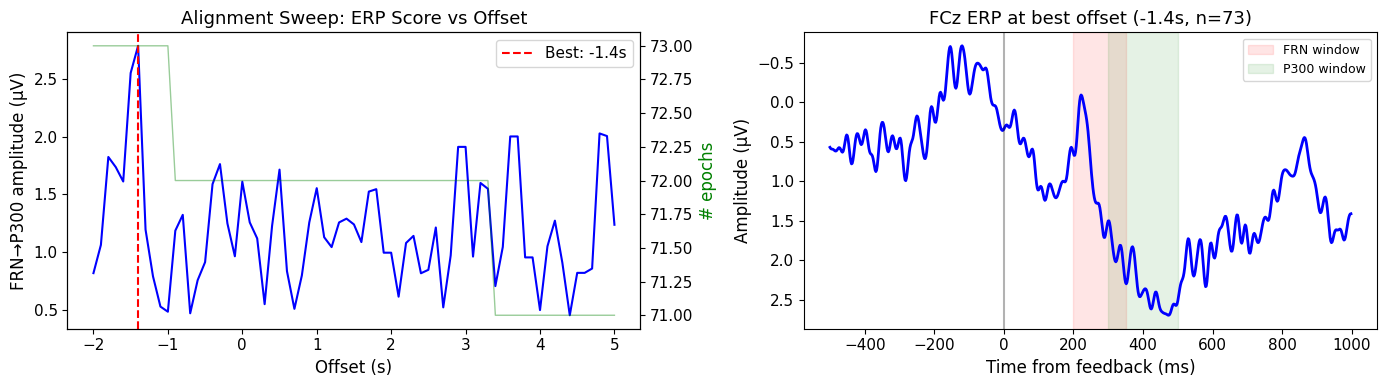


→ Using offset = -1.4s for all subsequent analyses


In [24]:
def epoch_at_offset(eeg, srate, event_times_sec, offset_sec, tmin, tmax, reject_uv=200):
    """Extract epochs with a given timing offset applied to event times."""
    n_pre = int(round(abs(tmin) * srate))
    n_post = int(round(tmax * srate))
    n_epoch = n_pre + n_post
    times = np.arange(n_epoch) / srate + tmin
    
    epochs = []
    kept_idx = []
    for i, t in enumerate(event_times_sec):
        center = int(round((t + offset_sec) * srate))
        s0, s1 = center - n_pre, center + n_post
        if s0 < 0 or s1 > len(eeg):
            continue
        ep = eeg[s0:s1]
        if ep.shape[0] != n_epoch:
            continue
        if np.max(np.abs(ep)) > reject_uv:
            continue
        epochs.append(ep)
        kept_idx.append(i)
    
    if not epochs:
        return np.empty((0, n_epoch, eeg.shape[1])), times, kept_idx
    return np.stack(epochs), times, kept_idx

# ── Sweep offsets from -2 to +5 seconds ──
offsets = np.arange(-2.0, 5.01, 0.1)
fcz_idx = ch_names.index('FCz')
feedback_times = bdf['feedback_onset'].values

frn_scores = []
n_epochs_per_offset = []

for off in offsets:
    epochs, times, kept = epoch_at_offset(
        eeg_clean, SRATE, feedback_times, off, -0.5, 1.0, reject_uv=300
    )
    n_epochs_per_offset.append(len(kept))
    if len(kept) < 10:
        frn_scores.append(0)
        continue
    
    # ERP at FCz
    erp = np.mean(epochs[:, :, fcz_idx], axis=0)
    # Baseline correct (-0.3 to -0.05s)
    bl_mask = (times >= -0.3) & (times <= -0.05)
    erp -= np.mean(erp[bl_mask])
    
    # FRN score: negative deflection around 200-350ms
    frn_mask = (times >= 0.2) & (times <= 0.35)
    # P300 score: positive deflection around 300-500ms  
    p3_mask = (times >= 0.3) & (times <= 0.5)
    
    # Combined: maximize the FRN-to-P300 transition (peak-to-trough)
    frn_amp = np.min(erp[frn_mask])  # most negative in FRN window
    p3_amp = np.max(erp[p3_mask])    # most positive in P300 window
    score = p3_amp - frn_amp  # larger = sharper ERP
    frn_scores.append(score)

frn_scores = np.array(frn_scores)
best_offset_idx = np.argmax(frn_scores)
BEST_OFFSET = offsets[best_offset_idx]

print(f"Best alignment offset: {BEST_OFFSET:.1f} s")
print(f"  FRN/P300 score: {frn_scores[best_offset_idx]:.2f} µV")
print(f"  Epochs retained: {n_epochs_per_offset[best_offset_idx]}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(offsets, frn_scores, 'b-', linewidth=1.5)
ax1.axvline(BEST_OFFSET, color='red', linestyle='--', label=f'Best: {BEST_OFFSET:.1f}s')
ax1.set_xlabel('Offset (s)')
ax1.set_ylabel('FRN→P300 amplitude (µV)')
ax1.set_title('Alignment Sweep: ERP Score vs Offset')
ax1.legend()

ax2b = ax1.twinx()
ax2b.plot(offsets, n_epochs_per_offset, 'g-', alpha=0.4, linewidth=1)
ax2b.set_ylabel('# epochs', color='green')

# Show ERP at best offset
epochs_best, times_best, kept_best = epoch_at_offset(
    eeg_clean, SRATE, feedback_times, BEST_OFFSET, -0.5, 1.0, reject_uv=300
)
erp_best = np.mean(epochs_best[:, :, fcz_idx], axis=0)
bl_mask = (times_best >= -0.3) & (times_best <= -0.05)
erp_best -= np.mean(erp_best[bl_mask])

ax2.plot(times_best * 1000, erp_best, 'b-', linewidth=2)
ax2.axvline(0, color='black', linestyle='-', alpha=0.3)
ax2.axvspan(200, 350, alpha=0.1, color='red', label='FRN window')
ax2.axvspan(300, 500, alpha=0.1, color='green', label='P300 window')
ax2.set_xlabel('Time from feedback (ms)')
ax2.set_ylabel('Amplitude (µV)')
ax2.set_title(f'FCz ERP at best offset ({BEST_OFFSET:.1f}s, n={len(kept_best)})')
ax2.legend(fontsize=9)
ax2.invert_yaxis()  # ERP convention: negative up

fig.tight_layout()
plt.show()

print(f"\n→ Using offset = {BEST_OFFSET:.1f}s for all subsequent analyses")


## Step 4: Verify Alignment — Feedback ERP by Condition

Total epochs: 71 (rejected: 3)
  Win:  40
  Loss: 31


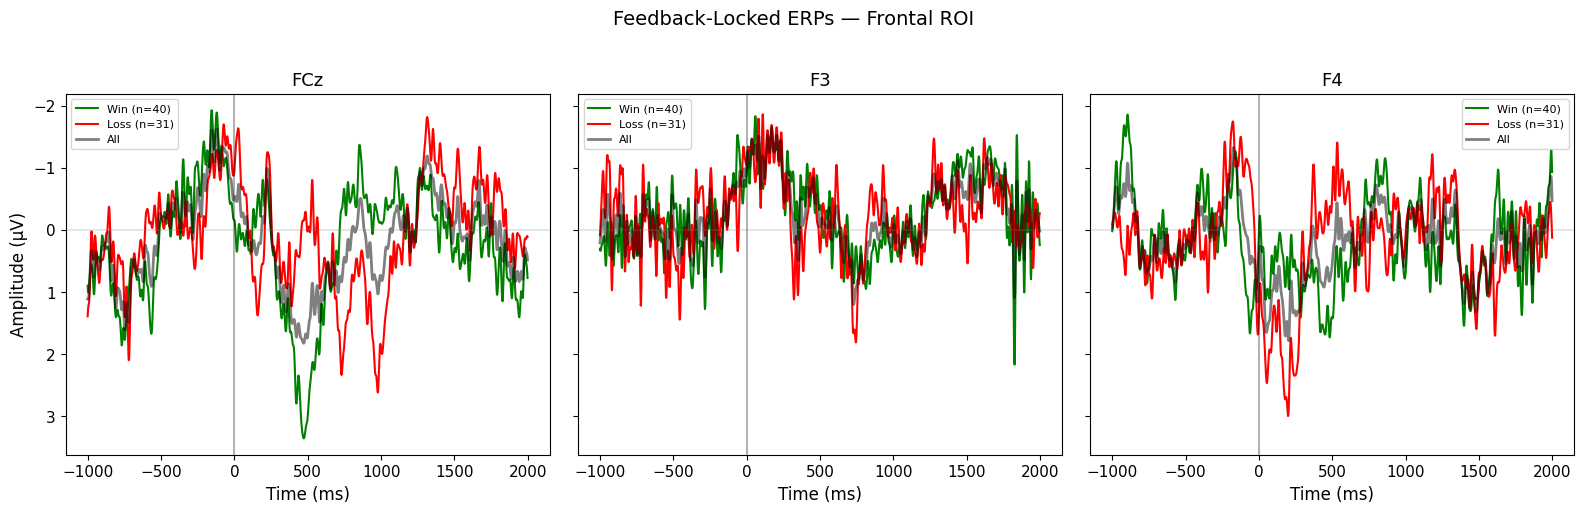

In [27]:
# Extract full epochs with verified offset
epochs_all, times_ep, kept_all = epoch_at_offset(
    eeg_clean, SRATE, feedback_times, BEST_OFFSET,
    EPOCH_TMIN, EPOCH_TMAX, reject_uv=EPOCH_REJECT_UV
)

# Split by reward
reward_flags = bdf['reward'].values[kept_all]
ep_win = epochs_all[reward_flags]
ep_loss = epochs_all[~reward_flags]

print(f"Total epochs: {len(epochs_all)} (rejected: {len(bdf) - len(kept_all)})")
print(f"  Win:  {len(ep_win)}")
print(f"  Loss: {len(ep_loss)}")

# Plot ERPs for frontal channels
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
frontal_idx = [ch_names.index(c) for c in FRONTAL_ROI if c in ch_names]

for ax, ci in zip(axes, frontal_idx):
    bl = (times_ep >= BASELINE_WIN[0]) & (times_ep <= BASELINE_WIN[1])
    
    erp_w = np.mean(ep_win[:, :, ci], axis=0)
    erp_w -= np.mean(erp_w[bl])
    erp_l = np.mean(ep_loss[:, :, ci], axis=0)
    erp_l -= np.mean(erp_l[bl])
    erp_a = np.mean(epochs_all[:, :, ci], axis=0)
    erp_a -= np.mean(erp_a[bl])
    
    ax.plot(times_ep*1000, erp_w, 'g-', linewidth=1.5, label=f'Win (n={len(ep_win)})')
    ax.plot(times_ep*1000, erp_l, 'r-', linewidth=1.5, label=f'Loss (n={len(ep_loss)})')
    ax.plot(times_ep*1000, erp_a, 'k-', linewidth=2, alpha=0.5, label='All')
    ax.axvline(0, color='black', linestyle='-', alpha=0.3)
    ax.axhline(0, color='gray', linestyle='-', alpha=0.2)
    ax.set_xlabel('Time (ms)')
    ax.set_title(ch_names[ci])
    ax.legend(fontsize=8)
    ax.invert_yaxis()

axes[0].set_ylabel('Amplitude (µV)')
fig.suptitle('Feedback-Locked ERPs — Frontal ROI', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


## Step 5: PLV-Based Theta Estimation (Reinhart & Nguyen Method)

For each frequency from 4–8 Hz (0.25 Hz steps):
1. Bandpass-filter each epoch (narrow band: ±0.5 Hz around center frequency)
2. Extract instantaneous phase via Hilbert transform
3. Compute PLV across trials for each frontal↔posterior channel pair during the feedback window
4. Average PLV across channel pairs

The frequency with maximum PLV = individualized theta frequency.


In [30]:
def compute_plv_spectrum(epochs, srate, ch_idx_a, ch_idx_b, times, 
                         win, freqs, bw=1.0):
    """
    Compute PLV between two channel groups across a range of frequencies.
    
    Parameters
    ----------
    epochs : (n_epochs, n_times, n_channels)
    ch_idx_a, ch_idx_b : lists of channel indices for the two groups
    times : time vector for epochs
    win : (t_start, t_end) analysis window in seconds
    freqs : array of center frequencies
    bw : bandwidth of narrowband filter (±bw/2 Hz around center)
    
    Returns
    -------
    plv_spectrum : array of mean PLV at each frequency
    plv_by_pair : dict of PLV per channel pair
    """
    win_mask = (times >= win[0]) & (times <= win[1])
    n_epochs = len(epochs)
    nyq = srate / 2.0
    
    plv_spectrum = np.zeros(len(freqs))
    plv_by_pair = {}
    
    for fi, fc in enumerate(freqs):
        lo = max(fc - bw/2, 0.5)
        hi = min(fc + bw/2, nyq - 1)
        if lo >= hi:
            continue
        
        # Narrowband filter
        b, a = signal.butter(3, [lo/nyq, hi/nyq], btype='band')
        
        pair_plvs = []
        for ci_a in ch_idx_a:
            for ci_b in ch_idx_b:
                # Filter and extract phase for each epoch
                phases_a = np.zeros((n_epochs, win_mask.sum()))
                phases_b = np.zeros((n_epochs, win_mask.sum()))
                
                for ei in range(n_epochs):
                    filt_a = signal.filtfilt(b, a, epochs[ei, :, ci_a])
                    filt_b = signal.filtfilt(b, a, epochs[ei, :, ci_b])
                    phases_a[ei] = np.angle(signal.hilbert(filt_a)[win_mask])
                    phases_b[ei] = np.angle(signal.hilbert(filt_b)[win_mask])
                
                # PLV: consistency of phase difference across trials
                phase_diff = phases_a - phases_b
                plv = np.abs(np.mean(np.exp(1j * phase_diff), axis=0))
                mean_plv = np.mean(plv)  # average across time points in window
                pair_plvs.append(mean_plv)
                
                pair_key = f"{ch_names[ci_a]}-{ch_names[ci_b]}"
                if pair_key not in plv_by_pair:
                    plv_by_pair[pair_key] = []
                plv_by_pair[pair_key].append((fc, mean_plv))
        
        plv_spectrum[fi] = np.mean(pair_plvs)
    
    return plv_spectrum, plv_by_pair

# ── Compute PLV across theta band ──
theta_freqs = np.arange(THETA_LO, THETA_HI + THETA_STEP/2, THETA_STEP)

frontal_idx = [ch_names.index(c) for c in FRONTAL_ROI if c in ch_names and ch_names.index(c) not in BAD_CH_IDX]
posterior_idx = [ch_names.index(c) for c in POSTERIOR_ROI if c in ch_names and ch_names.index(c) not in BAD_CH_IDX]

print(f"Frontal channels: {[ch_names[i] for i in frontal_idx]}")
print(f"Posterior channels: {[ch_names[i] for i in posterior_idx]}")
print(f"Frequency range: {theta_freqs[0]:.2f} – {theta_freqs[-1]:.2f} Hz ({len(theta_freqs)} steps)")
print(f"Analysis window: {THETA_WIN[0]}–{THETA_WIN[1]}s post-feedback")
print(f"Computing PLV...", end=' ')

t0 = time.time()
plv_spectrum, plv_by_pair = compute_plv_spectrum(
    epochs_all, SRATE, frontal_idx, posterior_idx,
    times_ep, THETA_WIN, theta_freqs, bw=1.0
)
print(f"done ({time.time()-t0:.1f}s)")

# Peak PLV frequency
best_plv_idx = np.argmax(plv_spectrum)
ITF_PLV = theta_freqs[best_plv_idx]
print(f"\n→ Peak PLV frequency: {ITF_PLV:.2f} Hz (PLV = {plv_spectrum[best_plv_idx]:.4f})")


Frontal channels: ['FCz', 'F3', 'F4']
Posterior channels: ['FT7', 'P3', 'P4']
Frequency range: 4.00 – 8.00 Hz (17 steps)
Analysis window: 0.1–1.5s post-feedback
Computing PLV... done (6.2s)

→ Peak PLV frequency: 7.50 Hz (PLV = 0.2982)


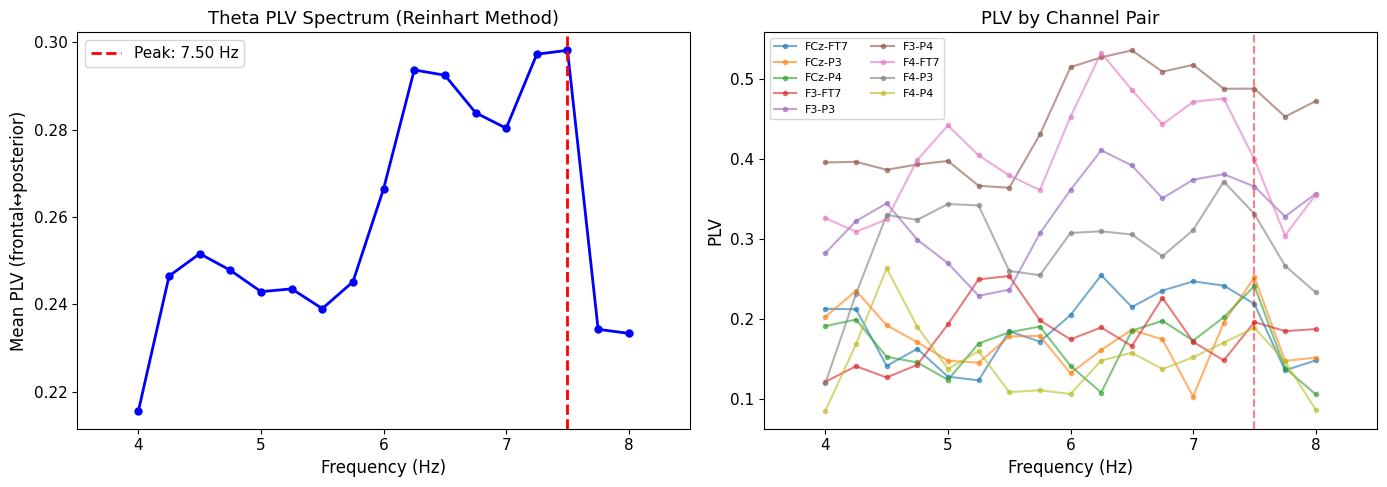

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Mean PLV spectrum ──
ax1.plot(theta_freqs, plv_spectrum, 'b-o', linewidth=2, markersize=5)
ax1.axvline(ITF_PLV, color='red', linestyle='--', linewidth=2,
            label=f'Peak: {ITF_PLV:.2f} Hz')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Mean PLV (frontal↔posterior)')
ax1.set_title('Theta PLV Spectrum (Reinhart Method)')
ax1.legend()
ax1.set_xlim(THETA_LO - 0.5, THETA_HI + 0.5)

# ── PLV by channel pair ──
for pair_name, pair_data in plv_by_pair.items():
    freqs_p, plvs_p = zip(*pair_data)
    ax2.plot(freqs_p, plvs_p, '-o', markersize=3, alpha=0.6, label=pair_name)

ax2.axvline(ITF_PLV, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('PLV')
ax2.set_title('PLV by Channel Pair')
ax2.legend(fontsize=8, ncol=2)
ax2.set_xlim(THETA_LO - 0.5, THETA_HI + 0.5)

fig.tight_layout()
plt.show()


## Step 6: Power-Based Theta Estimation (Time-Frequency Decomposition)

Morlet wavelet decomposition of feedback-locked epochs at the frontal ROI. The frequency of peak event-related power in the theta band during the feedback window provides a second, independent estimate.


In [35]:
def morlet_tfr(epochs, srate, freqs, n_cycles=5, ch_idx=None):
    """Compute time-frequency power via Morlet wavelets."""
    n_ep, n_times, n_ch = epochs.shape
    if ch_idx is None:
        ch_idx = list(range(n_ch))
    
    power = np.zeros((len(freqs), n_times))
    
    for fi, f in enumerate(freqs):
        # Morlet wavelet
        sigma_t = n_cycles / (2 * np.pi * f)
        hw = int(np.ceil(3.5 * sigma_t * srate))
        t_wav = np.arange(-hw, hw+1) / srate
        wav = np.exp(2j*np.pi*f*t_wav) * np.exp(-t_wav**2 / (2*sigma_t**2))
        wav /= np.sqrt(np.sum(np.abs(wav)**2))
        
        for ci in ch_idx:
            for ei in range(n_ep):
                analytic = signal.fftconvolve(epochs[ei, :, ci], wav, mode='same')
                power[fi] += np.abs(analytic)**2
        
        power[fi] /= (n_ep * len(ch_idx))
    
    return power

# Wider frequency range for visualization
tfr_freqs = np.arange(2.0, 15.25, 0.25)
frontal_ch_idx = [ch_names.index(c) for c in FRONTAL_ROI if c in ch_names and ch_names.index(c) not in BAD_CH_IDX]

print(f"Computing TFR ({len(tfr_freqs)} freqs × {len(epochs_all)} epochs)...", end=' ')
t0 = time.time()
tfr_power = morlet_tfr(epochs_all, SRATE, tfr_freqs, n_cycles=5, ch_idx=frontal_ch_idx)
print(f"done ({time.time()-t0:.1f}s)")

# Baseline correction (dB)
bl_mask = (times_ep >= BASELINE_WIN[0]) & (times_ep <= BASELINE_WIN[1])
baseline = np.mean(tfr_power[:, bl_mask], axis=1, keepdims=True)
baseline = np.maximum(baseline, 1e-30)
tfr_db = 10 * np.log10(np.maximum(tfr_power, 1e-30) / baseline)

# Extract theta spectrum in feedback window
theta_mask_f = (tfr_freqs >= THETA_LO) & (tfr_freqs <= THETA_HI)
theta_win_t = (times_ep >= THETA_WIN[0]) & (times_ep <= THETA_WIN[1])
theta_spectrum = np.mean(tfr_db[theta_mask_f][:, theta_win_t], axis=1)
theta_freqs_tfr = tfr_freqs[theta_mask_f]

# Smooth and find peak
from scipy.ndimage import gaussian_filter1d
theta_smooth = gaussian_filter1d(theta_spectrum, sigma=1.0)
peak_idx = np.argmax(theta_smooth)
ITF_POWER = theta_freqs_tfr[peak_idx]
print(f"\n→ Peak power frequency: {ITF_POWER:.2f} Hz ({theta_smooth[peak_idx]:.2f} dB)")


Computing TFR (53 freqs × 71 epochs)... done (1.4s)

→ Peak power frequency: 5.00 Hz (-0.24 dB)


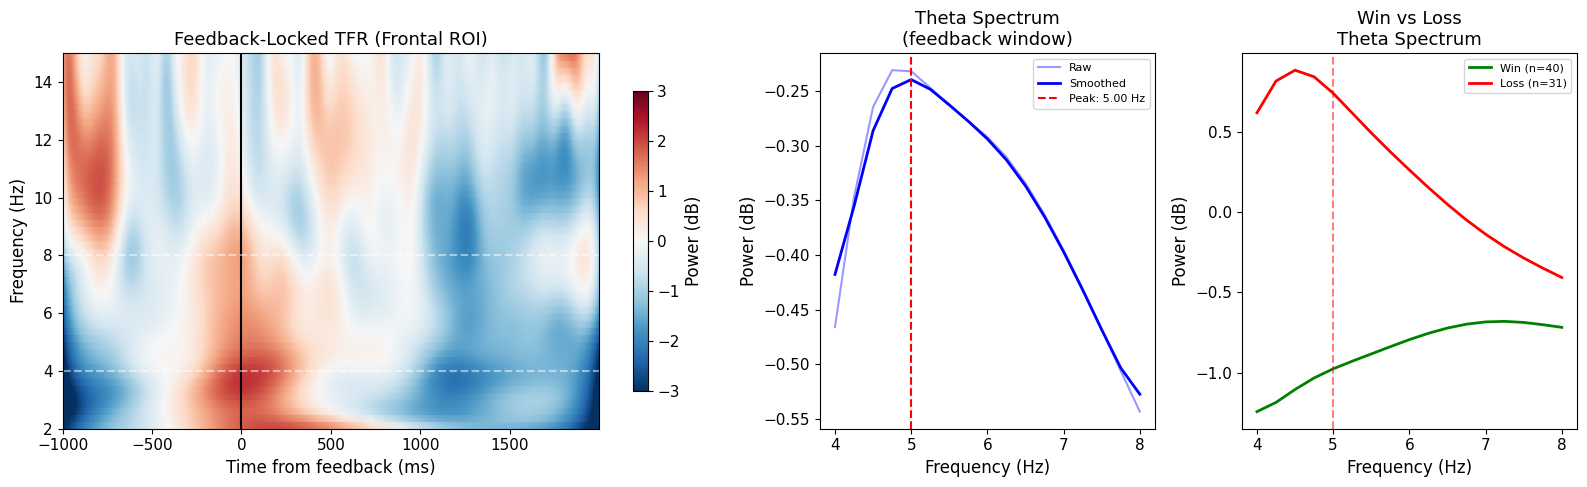

In [37]:
fig = plt.figure(figsize=(16, 5))
gs = GridSpec(1, 3, width_ratios=[2, 1, 1])

# ── TFR heatmap ──
ax1 = fig.add_subplot(gs[0])
im = ax1.pcolormesh(times_ep*1000, tfr_freqs, tfr_db, 
                     shading='gouraud', cmap='RdBu_r', vmin=-3, vmax=3)
ax1.axvline(0, color='black', linewidth=1.5)
ax1.axhline(THETA_LO, color='white', linestyle='--', alpha=0.5)
ax1.axhline(THETA_HI, color='white', linestyle='--', alpha=0.5)
ax1.set_xlabel('Time from feedback (ms)')
ax1.set_ylabel('Frequency (Hz)')
ax1.set_title('Feedback-Locked TFR (Frontal ROI)')
fig.colorbar(im, ax=ax1, label='Power (dB)', shrink=0.8)

# ── Theta power spectrum in feedback window ──
ax2 = fig.add_subplot(gs[1])
ax2.plot(theta_freqs_tfr, theta_spectrum, 'b-', alpha=0.4, label='Raw')
ax2.plot(theta_freqs_tfr, theta_smooth, 'b-', linewidth=2, label='Smoothed')
ax2.axvline(ITF_POWER, color='red', linestyle='--', label=f'Peak: {ITF_POWER:.2f} Hz')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Power (dB)')
ax2.set_title('Theta Spectrum\n(feedback window)')
ax2.legend(fontsize=8)

# ── Win vs Loss theta spectrum ──
ax3 = fig.add_subplot(gs[2])
reward_flags = bdf['reward'].values[kept_all]
tfr_win = morlet_tfr(ep_win, SRATE, theta_freqs_tfr, n_cycles=5, ch_idx=frontal_ch_idx)
tfr_loss = morlet_tfr(ep_loss, SRATE, theta_freqs_tfr, n_cycles=5, ch_idx=frontal_ch_idx)

bl_w = np.mean(tfr_win[:, bl_mask], axis=1, keepdims=True)
bl_l = np.mean(tfr_loss[:, bl_mask], axis=1, keepdims=True)
spec_w = np.mean(10*np.log10(np.maximum(tfr_win[:, theta_win_t], 1e-30) / np.maximum(bl_w, 1e-30)), axis=1)
spec_l = np.mean(10*np.log10(np.maximum(tfr_loss[:, theta_win_t], 1e-30) / np.maximum(bl_l, 1e-30)), axis=1)

ax3.plot(theta_freqs_tfr, spec_w, 'g-', linewidth=2, label=f'Win (n={len(ep_win)})')
ax3.plot(theta_freqs_tfr, spec_l, 'r-', linewidth=2, label=f'Loss (n={len(ep_loss)})')
ax3.axvline(ITF_POWER, color='red', linestyle='--', alpha=0.5)
ax3.set_xlabel('Frequency (Hz)')
ax3.set_ylabel('Power (dB)')
ax3.set_title('Win vs Loss\nTheta Spectrum')
ax3.legend(fontsize=8)

fig.tight_layout()
plt.show()


## Step 7: Specparam on Feedback-Locked Spectrum

Unlike the resting-state analysis (which found no theta peak because FM-theta is event-evoked), here we compute the PSD specifically from the feedback window of each epoch, average across epochs, and run specparam. Since we're isolating the time window where theta *should* be active, a genuine oscillatory peak should emerge above the aperiodic background.



	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Specparam on feedback-locked frontal spectrum:
  Aperiodic: offset=0.200, exponent=1.298
  R² = 0.9918
  Detected peaks:
    4.60 Hz (power=0.156, bw=2.47) ← THETA
    11.38 Hz (power=0.188, bw=1.88) ← alpha

→ Specparam theta peak: 4.60 Hz (power=0.156)


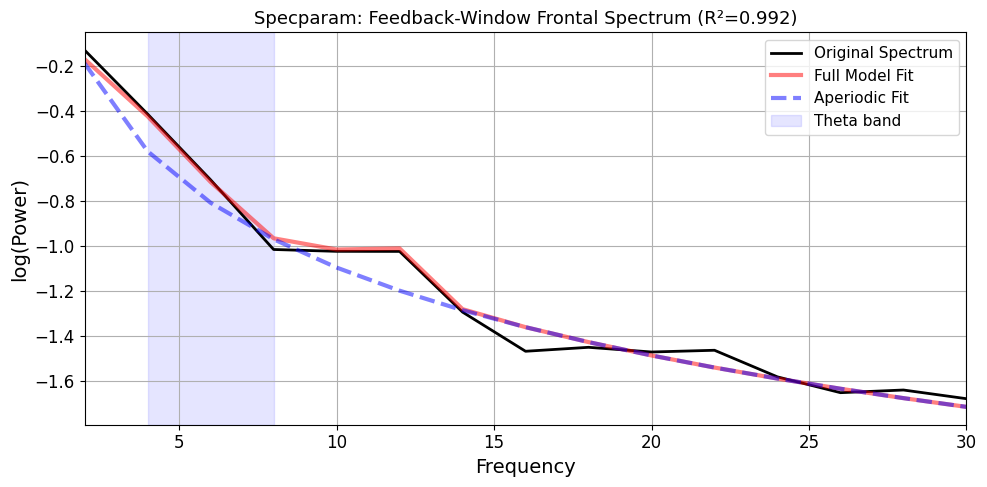

In [40]:
if SPECPARAM_AVAILABLE:
    # Extract feedback window segments from each epoch
    win_mask = (times_ep >= THETA_WIN[0]) & (times_ep <= THETA_WIN[1])
    frontal_epochs_win = epochs_all[:, win_mask][:, :, frontal_ch_idx]
    
    # Average across frontal channels, then compute Welch PSD per epoch and average
    frontal_mean = np.mean(frontal_epochs_win, axis=2)  # (n_epochs, n_times)
    
    # Welch on each epoch, then average
    nperseg = min(int(SRATE * 0.5), frontal_mean.shape[1])  # 0.5s segments
    psds = []
    for ei in range(len(frontal_mean)):
        f, p = signal.welch(frontal_mean[ei], fs=SRATE, nperseg=nperseg, 
                            noverlap=nperseg//2, window='hann')
        psds.append(p)
    
    avg_psd = np.mean(psds, axis=0)
    
    # Fit specparam
    sm = SpectralModel(
        peak_width_limits=[1.0, 6.0],
        max_n_peaks=4,
        min_peak_height=0.1,
        aperiodic_mode='fixed',
    )
    sm.fit(f, avg_psd, freq_range=[2, 30])
    
    ap = sm.results.params.aperiodic.params
    pk = sm.results.params.periodic.params
    r2 = sm.results.metrics.results['gof_rsquared']
    
    print(f"Specparam on feedback-locked frontal spectrum:")
    print(f"  Aperiodic: offset={ap[0]:.3f}, exponent={ap[1]:.3f}")
    print(f"  R² = {r2:.4f}")
    
    ITF_SPECPARAM = None
    if pk.size > 0 and pk.ndim == 2:
        print(f"  Detected peaks:")
        for p in pk:
            band = ''
            if THETA_LO <= p[0] <= THETA_HI: band = ' ← THETA'
            if 8 <= p[0] <= 13: band = ' ← alpha'
            print(f"    {p[0]:.2f} Hz (power={p[1]:.3f}, bw={p[2]:.2f}){band}")
            if THETA_LO <= p[0] <= THETA_HI and (ITF_SPECPARAM is None or p[1] > ITF_SPECPARAM[1]):
                ITF_SPECPARAM = (p[0], p[1])
    
    if ITF_SPECPARAM:
        print(f"\n→ Specparam theta peak: {ITF_SPECPARAM[0]:.2f} Hz (power={ITF_SPECPARAM[1]:.3f})")
        ITF_SPECPARAM = ITF_SPECPARAM[0]
    else:
        print("\n→ No theta peak detected by specparam in feedback window")
        ITF_SPECPARAM = None
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    sm.plot(ax=ax, plt_log=False)
    ax.axvspan(THETA_LO, THETA_HI, alpha=0.1, color='blue', label='Theta band')
    ax.set_title(f'Specparam: Feedback-Window Frontal Spectrum (R²={r2:.3f})')
    ax.set_xlim(2, 30)
    ax.legend()
    fig.tight_layout()
    plt.show()

else:
    ITF_SPECPARAM = None
    print("specparam not available")


## Step 8: Consolidated Frequency Estimate

Cross-reference the three methods and select the individualized theta frequency with confidence rating, following Reinhart & Nguyen's 0.5 Hz resolution convention.


In [43]:
# ══════════════════════════════════════════════════════════════════
# DECISION LOGIC
# ══════════════════════════════════════════════════════════════════

estimates = {
    'PLV (Reinhart)': ITF_PLV,
    'Power (TFR)': ITF_POWER,
    'Specparam': ITF_SPECPARAM,
}

valid = {k: v for k, v in estimates.items() if v is not None}

print("╔═══════════════════════════════════════════════════════════════╗")
print("║        INDIVIDUALIZED THETA FREQUENCY ESTIMATES              ║")
print("╠═══════════════════════════════════════════════════════════════╣")

for name, freq in estimates.items():
    status = f"{freq:.2f} Hz" if freq is not None else "no peak"
    print(f"║  {name:<20}: {status:<40}║")

# Decision
if len(valid) >= 2:
    freqs_list = list(valid.values())
    mean_est = np.mean(freqs_list)
    spread = np.max(freqs_list) - np.min(freqs_list)
    
    if spread <= 1.0:
        confidence = "HIGH"
        recommended = mean_est
    elif spread <= 2.0:
        confidence = "MODERATE"
        recommended = valid.get('PLV (Reinhart)', mean_est)  # prefer PLV
    else:
        confidence = "LOW"
        recommended = valid.get('PLV (Reinhart)', 6.0)
elif len(valid) == 1:
    confidence = "LOW (single estimate)"
    recommended = list(valid.values())[0]
else:
    confidence = "NONE — fallback"
    recommended = 6.0

# Round to 0.5 Hz (Reinhart convention: round up from .3)
recommended_rounded = np.round(recommended * 2) / 2
# Clamp to theta band
recommended_rounded = max(THETA_LO, min(THETA_HI, recommended_rounded))

print(f"║                                                             ║")
print(f"║  Mean estimate: {np.mean(list(valid.values())):.2f} Hz  (spread: {np.max(list(valid.values()))-np.min(list(valid.values())):.2f} Hz)" .ljust(62) + "║" if valid else "")
print(f"║  ▶ RECOMMENDED iTF: {recommended_rounded:.1f} Hz  [{confidence}]".ljust(62) + "║")
print(f"║  (rounded to 0.5 Hz per Reinhart & Nguyen convention)".ljust(62) + "║")
print("╚═══════════════════════════════════════════════════════════════╝")


╔═══════════════════════════════════════════════════════════════╗
║        INDIVIDUALIZED THETA FREQUENCY ESTIMATES              ║
╠═══════════════════════════════════════════════════════════════╣
║  PLV (Reinhart)      : 7.50 Hz                                 ║
║  Power (TFR)         : 5.00 Hz                                 ║
║  Specparam           : 4.60 Hz                                 ║
║                                                             ║
║  Mean estimate: 5.70 Hz  (spread: 2.90 Hz)                  ║
║  ▶ RECOMMENDED iTF: 7.5 Hz  [LOW]                           ║
║  (rounded to 0.5 Hz per Reinhart & Nguyen convention)       ║
╚═══════════════════════════════════════════════════════════════╝


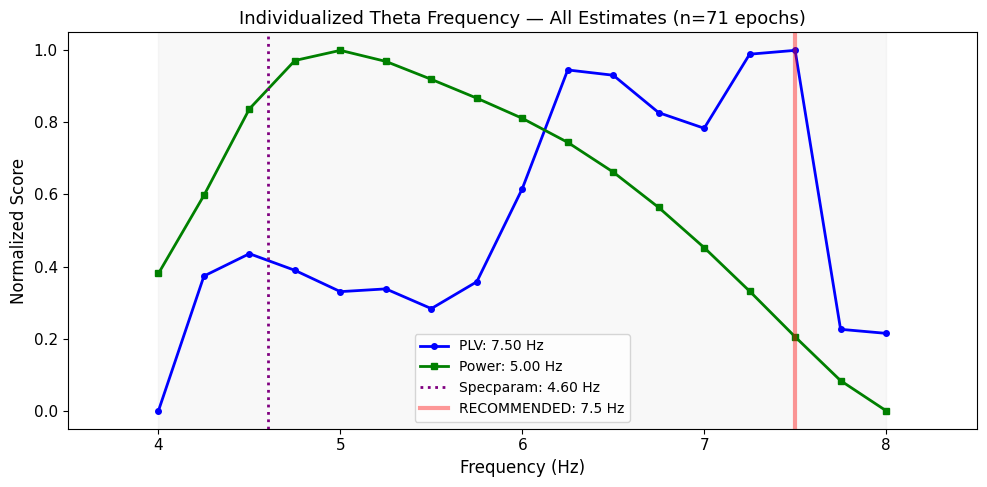

In [45]:
# Summary figure: all three estimates on one plot
fig, ax = plt.subplots(figsize=(10, 5))

# Normalize PLV and power spectra to [0,1] for overlay
plv_norm = (plv_spectrum - plv_spectrum.min()) / (plv_spectrum.max() - plv_spectrum.min() + 1e-12)
pow_norm = (theta_smooth - theta_smooth.min()) / (theta_smooth.max() - theta_smooth.min() + 1e-12)

ax.plot(theta_freqs, plv_norm, 'b-o', linewidth=2, markersize=4, label=f'PLV: {ITF_PLV:.2f} Hz')
ax.plot(theta_freqs_tfr, pow_norm, 'g-s', linewidth=2, markersize=4, label=f'Power: {ITF_POWER:.2f} Hz')

if ITF_SPECPARAM is not None:
    ax.axvline(ITF_SPECPARAM, color='purple', linestyle=':', linewidth=2,
               label=f'Specparam: {ITF_SPECPARAM:.2f} Hz')

ax.axvline(recommended_rounded, color='red', linestyle='-', linewidth=3, alpha=0.4,
           label=f'RECOMMENDED: {recommended_rounded:.1f} Hz')

ax.axvspan(THETA_LO, THETA_HI, alpha=0.05, color='gray')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Normalized Score')
ax.set_title(f'Individualized Theta Frequency — All Estimates (n={len(epochs_all)} epochs)')
ax.legend(fontsize=10)
ax.set_xlim(THETA_LO - 0.5, THETA_HI + 0.5)

fig.tight_layout()
plt.show()


## Step 9: Export

In [48]:
import json
from datetime import datetime

export = {
    'subject_id': bdf['subject_id'].iloc[0],
    'session': int(bdf['session'].iloc[0]),
    'run': int(bdf['run'].iloc[0]),
    'created_at': datetime.now().isoformat(),
    'method': 'feedback_locked_plv_and_power',
    'reference': 'Reinhart & Nguyen (2019) Nature Neuroscience',
    'alignment_offset_sec': float(BEST_OFFSET),
    'n_epochs_total': len(epochs_all),
    'n_epochs_win': len(ep_win),
    'n_epochs_loss': len(ep_loss),
    'estimates': {
        'plv_based_hz': float(ITF_PLV),
        'plv_peak_value': float(plv_spectrum[best_plv_idx]),
        'power_based_hz': float(ITF_POWER),
        'specparam_hz': float(ITF_SPECPARAM) if ITF_SPECPARAM else None,
    },
    'recommended_itf_hz': float(recommended_rounded),
    'confidence': confidence,
    'theta_band_hz': [THETA_LO, THETA_HI],
    'analysis_window_sec': list(THETA_WIN),
    'frontal_roi': FRONTAL_ROI,
    'posterior_roi': POSTERIOR_ROI,
}

# Uncomment to save:
# out_path = BEHAV_CSV.parent / f"{bdf['subject_id'].iloc[0]}_itf_estimate.json"
# with open(out_path, 'w') as f:
#     json.dump(export, f, indent=2)
# print(f"Saved to: {out_path}")

print(json.dumps(export, indent=2, default=str))


{
  "subject_id": "rebecca-pilot-2",
  "session": 1,
  "run": 1,
  "created_at": "2026-06-04T22:49:26.126411",
  "method": "feedback_locked_plv_and_power",
  "reference": "Reinhart & Nguyen (2019) Nature Neuroscience",
  "alignment_offset_sec": -1.3999999999999995,
  "n_epochs_total": 71,
  "n_epochs_win": 40,
  "n_epochs_loss": 31,
  "estimates": {
    "plv_based_hz": 7.5,
    "plv_peak_value": 0.29817661900718484,
    "power_based_hz": 5.0,
    "specparam_hz": 4.602684541406665
  },
  "recommended_itf_hz": 7.5,
  "confidence": "LOW",
  "theta_band_hz": [
    4.0,
    8.0
  ],
  "analysis_window_sec": [
    0.1,
    1.5
  ],
  "frontal_roi": [
    "FCz",
    "F3",
    "F4"
  ],
  "posterior_roi": [
    "FT7",
    "P3",
    "P4"
  ]
}


---

## Methodological Notes

**1. Reinhart & Nguyen (2019) adaptation:**
The original paper computed PLV in source space between left prefrontal and left temporal cortex during a working memory maintenance window (500–3000 ms). With 7 electrodes we can't do source localization, so we use sensor-space PLV between frontal (FCz, F3, F4) and posterior/lateral (FT7, P3, P4) channels during the feedback window (100–1500 ms). The logic is the same: find the theta frequency with maximum inter-regional phase synchronization during the cognitively relevant task epoch.

**2. Why three estimates?**
PLV captures *connectivity* (the Reinhart approach), power captures *local oscillatory strength*, and specparam distinguishes genuine oscillations from aperiodic slopes. Agreement across methods = high confidence. Disagreement = lower confidence, default to PLV (closest to the Reinhart method).

**3. Alignment verification:**
The ERP sweep is critical. Without it, a 1–2s timing error could place "feedback-locked" epochs during the wait period or ITI, yielding meaningless theta estimates. The FRN/P300 peak provides sub-second alignment verification.

**4. 0.5 Hz resolution:**
Following Reinhart & Nguyen: stimulation frequency is rounded to the nearest 0.5 Hz. An iTF of 5.7 Hz → 5.5 Hz; 5.8 Hz → 6.0 Hz.

**5. Fallback:**
If no method detects a clear theta peak (all fail prominence/reliability criteria), the canonical fallback is 6.0 Hz, which is the center of the theta band and the most common fixed frequency in the tACS literature.
